In [ ]:
import pandas as pd
import sqlite3

# 1. Cargamos los archivos CSV que descargaste
df_ops = pd.read_csv('C:\\Users\\HP\\Documents\\Bootcamp Data Analyst\\Proyectos\\Pronostico_volumen_QRO\\logistica_fedex_qro_ops.csv')
df_clima = pd.read_csv('C:\\Users\\HP\\Documents\\Bootcamp Data Analyst\\Proyectos\\Pronostico_volumen_QRO\\clima_qro_historico.csv')

# 2. Creamos una base de datos temporal en la memoria de mi PC para trabajar con SQL 
conn = sqlite3.connect(':memory:')

# 3. Metemos los datos de los CSV a tablas de SQL
df_ops.to_sql('tabla_ops', conn, index=False, if_exists='replace')
df_clima.to_sql('tabla_clima', conn, index=False, if_exists='replace')

print("¡Todo listo! Las tablas 'tabla_ops' y 'tabla_clima' ya están creadas en SQL.")

¡Todo listo! Las tablas 'tabla_ops' y 'tabla_clima' ya están creadas en SQL.


In [11]:
# Definimos la consulta SQL para unir las tablas por fecha
query_logistica = """
SELECT 
    ops.fecha, 
    ops.volumen_paquetes, 
    ops.vehiculos_terceros_contratados,
    clima.temp_media_c, 
    clima.probabilidad_lluvia
FROM 
    tabla_ops AS ops
JOIN 
    tabla_clima AS clima ON ops.fecha = clima.fecha
ORDER BY 
    ops.volumen_paquetes DESC
LIMIT 15;
"""

# Ejecutamos la consulta y la guardamos en un DataFrame
df_analisis = pd.read_sql_query(query_logistica, conn)

# Mostramos el resultado
df_analisis

#Esta info de la condición ON ops.fecha = clima.fecha le dice: "Solo junta las filas si la fecha coincide exactamente". Así puedo saber qué clima hubo específicamente el día que se movieron esos paquetes.
#El order by me permite ver de inmediato qué estaba pasando (clima y transporte) cuando la operación estuvo al límite

,fecha,volumen_paquetes,vehiculos_terceros_contratados,temp_media_c,probabilidad_lluvia
0,2024-12-22,24990,25,15.972954,0.049885
1,2025-11-13,24790,37,11.469532,0.296300
2,2024-12-30,24743,33,10.517991,0.215714
3,2025-11-02,24706,32,13.912754,0.055540
4,2025-11-29,24685,13,17.610703,0.253365
5,2025-11-03,24666,12,11.990027,0.162570
6,2025-12-15,24383,35,8.657086,0.187767
7,2024-10-27,24309,35,9.242972,0.054431
8,2024-12-08,24206,21,9.516749,0.061926
9,2025-10-13,24185,10,17.321183,0.100273


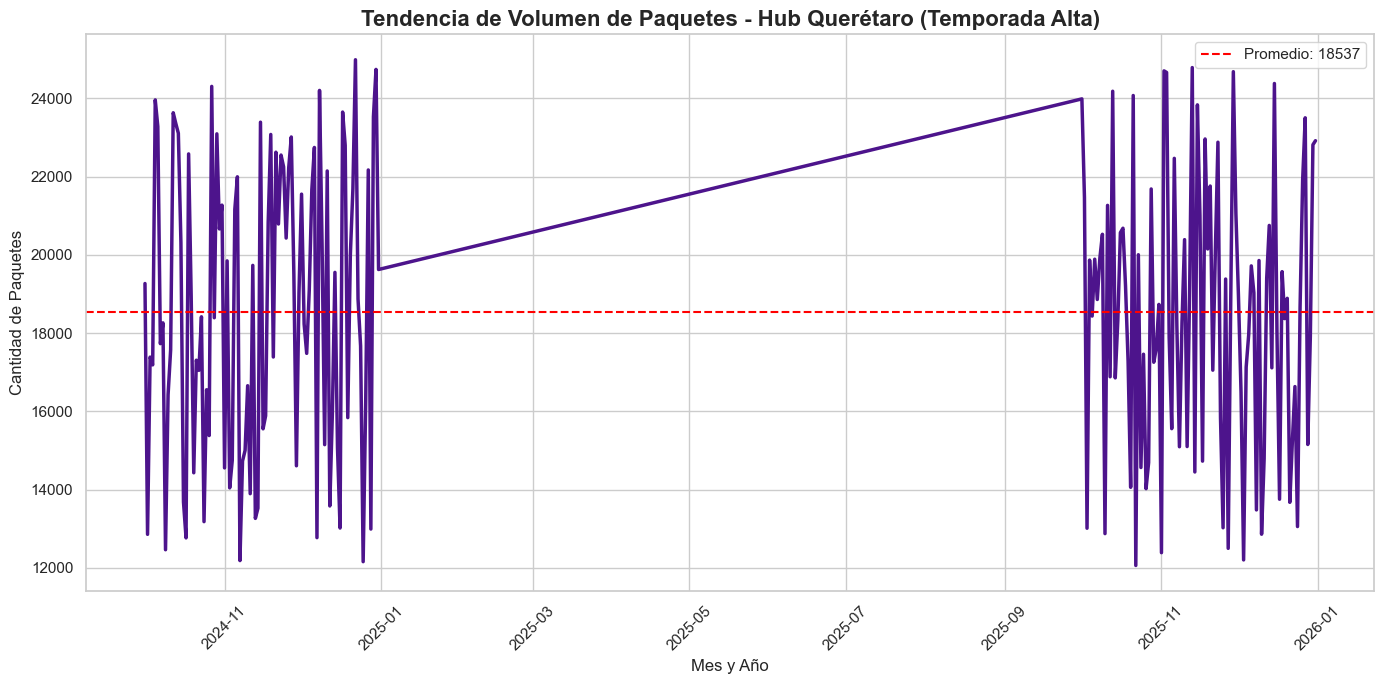

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga de los datos
# Asegúrate de que los nombres de los archivos coincidan con los que subiste
df_ops = pd.read_csv('logistica_fedex_qro_ops.csv')

# Es vital convertir la columna de fecha a formato datetime para que la gráfica sea correcta
df_ops['fecha'] = pd.to_datetime(df_ops['fecha'])

# 2. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 3. Graficar Volumen de Paquetes vs Tiempo
sns.lineplot(data=df_ops, x='fecha', y='volumen_paquetes', color='#4D148C', linewidth=2.5)

# Personalización para que se vea profesional
plt.title('Tendencia de Volumen de Paquetes - Hub Querétaro (Temporada Alta)', fontsize=16, fontweight='bold')
plt.xlabel('Mes y Año', fontsize=12)
plt.ylabel('Cantidad de Paquetes', fontsize=12)
plt.xticks(rotation=45)

# Añadir una línea promedio para referencia
promedio = df_ops['volumen_paquetes'].mean()
plt.axhline(promedio, color='red', linestyle='--', label=f'Promedio: {promedio:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Este Query divide tus datos por el promedio de lluvia que haya en el archivo
query_final_impacto = """
SELECT 
    CASE 
        WHEN clima.probabilidad_lluvia > (SELECT AVG(probabilidad_lluvia) FROM tabla_clima) THEN 'Días con Más Lluvia/Neblina'
        ELSE 'Días con Menos Lluvia (Despejado)'
    END AS estado_clima,
    AVG(ops.volumen_paquetes) AS promedio_volumen,
    COUNT(*) AS dias_observados
FROM 
    tabla_ops AS ops
JOIN 
    tabla_clima AS clima ON ops.fecha = clima.fecha
GROUP BY 
    estado_clima;
"""

df_impacto_final = pd.read_sql_query(query_final_impacto, conn)
df_impacto_final
# Este query nos muestra que cuando llueve manejamos un promedio 400 paquetes menos que cuando el clima está despejado.

,estado_clima,promedio_volumen,dias_observados
0,Días con Menos Lluvia (Despejado),18740.000000,90
1,Días con Más Lluvia/Neblina,18342.978723,94


In [25]:
# --- DATOS OPERATIVOS ---
costo_renta_tercero = 1800    # Costo fijo por día del proveedor
costo_operar_propio = 900     # Mantenimiento/sueldo diario prorrateado
utilidad_por_paquete = 15     # Lo que nos queda de margen libre por entrega

# --- CÁLCULO ---
# Queremos saber cuántos paquetes cubren la diferencia de costo entre un tercero y un propio
diferencia_costo = costo_renta_tercero - costo_operar_propio
punto_rentabilidad_extra = diferencia_costo / utilidad_por_paquete

print(f"--- PUNTO DE EQUILIBRIO DE TERCEROS ---")
print(f"Un vehículo de terceros se vuelve RENTABLE a partir de los {int(punto_rentabilidad_extra)} paquetes adicionales.")
print(f"Si el volumen cae por debajo de este número debido a la neblina, es mejor NO contratar.")

# Esto nos está diciendo que mi vehículo rentado se vuelve eficiente cuando el volumen de paquetes supera los 60 adicionales que normalmente movería,por lo que tenemos un promedio de 400 paquetes menos en días lluviosos, es imperativo no contratar mínimo 6 unidades.

--- PUNTO DE EQUILIBRIO DE TERCEROS ---
Un vehículo de terceros se vuelve RENTABLE a partir de los 60 paquetes adicionales.
Si el volumen cae por debajo de este número debido a la neblina, es mejor NO contratar.


In [29]:
import sys
!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 3.7 MB/s eta 0:00:03
   ------------------------ --------------- 5.0/8.1 MB 15.9 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 14.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 14.8 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.1/37.3 MB 19.3 MB/s eta 0:00:02
   ------- -------------------------------- 7.3/37.3 MB 17.3 MB/s eta 0:00:02
   ----------- ---------------------------- 11.0/37.3 MB 18.2 MB/s eta 0:00:02
   -------------- ------------------------- 13.1/37.3 MB 15.8 MB/s eta 0:00:02
   -------------------- ------------------- 18.9/37.3 MB 18.1 MB/s eta 0:00:02
   ------------------------ --------------- 22.8/37.3 MB 18.2 MB/s eta 0:00:01
   ---------------------------- ----------- 26.5/37.3 MB 18.3 MB/s eta 0:00:01
   ---


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# 1. CREAMOS EL DATAFRAME DESDE CERO
# Usamos un query que traiga los datos día por día (sin agrupar)
query_para_prediccion = """
SELECT 
    clima.probabilidad_lluvia, 
    ops.volumen_paquetes 
FROM tabla_ops AS ops
JOIN tabla_clima AS clima ON ops.fecha = clima.fecha
"""
df_modelo = pd.read_sql_query(query_para_prediccion, conn)

# 2. ENTRENAMOS EL MODELO
from sklearn.linear_model import LinearRegression

# Usamos el nombre exacto de las columnas que acabamos de traer
X = df_modelo[['probabilidad_lluvia']]
y = df_modelo['volumen_paquetes']

modelo_final = LinearRegression()
modelo_final.fit(X, y)

print("¡CONSEGUIDO! El modelo ha sido entrenado con los datos del Hub.")
print(f"Columnas detectadas: {df_modelo.columns.tolist()}")

¡CONSEGUIDO! El modelo ha sido entrenado con los datos del Hub.
Columnas detectadas: ['probabilidad_lluvia', 'volumen_paquetes']


In [43]:
def simulador_vianey(clima_mañana):
    prediccion = modelo_final.predict([[clima_mañana]])[0]
    caida = 18740 - prediccion # 18740 es el promedio en día despejado
    
    print(f"Volumen previsto: {int(prediccion)} paquetes")
    if caida > 60: # Tu punto de rentabilidad
        unidades = int(caida / 80)
        print(f"RECOMENDACIÓN: Cancelar {unidades} unidades de terceros en San Juan del Río.")
    else:
        print("RECOMENDACIÓN: Mantener operación normal.")

# Prueba con 0.3 de probabilidad de lluvia
simulador_vianey(0.3)

# Cuando escribo simulador_vianey(0.3), el modelo hace lo siguiente internamente:
# Toma el dato: 0.3 (30% de probabilidad de lluvia).
# Usa memoria: Busca la relación que aprendió de la tabla df_modelo (donde vio la historia del Hub QRO).

# Aplica la fórmula: Multiplica ese 0.3 por la "pendiente" que calculó y le suma el volumen base (lo que normalmente llegaría si no lloviera).

Volumen previsto: 18080 paquetes
RECOMENDACIÓN: Cancelar 8 unidades de terceros en San Juan del Río.


c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
